## Практическая работа - Разведочный анализ данных
### Набор данных: Wine Quality (UCI Machine Learning Repository)
Выполнил Кочуров А.Д. группа 2384

Описание задачи: Набор данных содержит физико-химические характеристики красных и белых вин португальского сорта "Vinho Verde". Целевой атрибут - оценка качества вина (от 0 до 10), выставленная экспертами-сомелье.

Аналитическая задача: определить, какие физико-химические параметры вина наиболее сильно влияют на его качество, и построить систему бинарной классификации "хорошее вино" (quality ≥ 7) / "обычное вино" (quality < 7).

Источник данных: P. Cortez et al., 2009. Modeling wine preferences by data mining from physicochemical properties. Decision Support Systems, 47(4):547-553.  
URL: https://archive.ics.uci.edu/ml/datasets/wine+quality

### 1. Подключение библиотек

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
import math

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.ticker import FormatStrFormatter

print(f'matplotlib version: {mpl.__version__}')
print(f'pandas version: {pd.__version__}')

matplotlib version: 3.10.0
pandas version: 2.2.2


### 2. Загрузка данных

Объединяем датасеты красного и белого вина. Добавляем номинальный атрибут `type` (red / white) и бинарный целевой атрибут `quality_label`: good (quality ≥ 7) / regular (quality < 7).

In [2]:
url_red   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red   = pd.read_csv(url_red,   sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red['type']   = 'red'
df_white['type'] = 'white'

df = pd.concat([df_red, df_white], ignore_index=True)

# Бинарный целевой признак
df['quality_label'] = df['quality'].apply(lambda q: 'good' if q >= 7 else 'regular')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
 13  quality_label         6497 non-null   object 
dtypes: float64(11), int64(1), object(2)
memory usage: 710.7+ KB


Состав датасета:
- Числовые признаки (11): fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
- Номинальный признак (1): type (red / white)
- Целевые атрибуты: quality (0–10), quality_label (good / regular)

Пропущенных значений нет - все 6497 записей полны.

In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Уже из `describe()` видно, что диапазоны признаков сильно различаются: например, `total sulfur dioxide` достигает 440, а `density` - около 1.0. Также максимальные значения некоторых признаков сильно отрываются от 75-го квантиля - первый признак возможных выбросов.

### 2.1. Описательные статистики - среднее, медиана, мода, СКО

In [4]:
numeric_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                'density', 'pH', 'sulphates', 'alcohol']

# Вычислим основные описательные статистики
stats = pd.DataFrame({
    'mean':   df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode':   df[numeric_cols].mode().iloc[0],   # первая мода
    'std':    df[numeric_cols].std(),
    'min':    df[numeric_cols].min(),
    'max':    df[numeric_cols].max(),
    'IQR':    df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
}).round(4)

print(stats.to_string())
stats

                          mean    median      mode      std     min      max      IQR
fixed acidity           7.2153    7.0000    6.8000   1.2964  3.8000   15.900   1.3000
volatile acidity        0.3397    0.2900    0.2800   0.1646  0.0800    1.580   0.1700
citric acid             0.3186    0.3100    0.3000   0.1453  0.0000    1.660   0.1400
residual sugar          5.4432    3.0000    2.0000   4.7578  0.6000   65.800   6.3000
chlorides               0.0560    0.0470    0.0440   0.0350  0.0090    0.611   0.0270
free sulfur dioxide    30.5253   29.0000   29.0000  17.7494  1.0000  289.000  24.0000
total sulfur dioxide  115.7446  118.0000  111.0000  56.5219  6.0000  440.000  79.0000
density                 0.9947    0.9949    0.9972   0.0030  0.9871    1.039   0.0047
pH                      3.2185    3.2100    3.1600   0.1608  2.7200    4.010   0.2100
sulphates               0.5313    0.5100    0.5000   0.1488  0.2200    2.000   0.1700
alcohol                10.4918   10.3000    9.5000   1

,mean,median,mode,std,min,max,IQR
fixed acidity,7.2153,7.0000,6.8000,1.2964,3.8000,15.900,1.3000
volatile acidity,0.3397,0.2900,0.2800,0.1646,0.0800,1.580,0.1700
citric acid,0.3186,0.3100,0.3000,0.1453,0.0000,1.660,0.1400
residual sugar,5.4432,3.0000,2.0000,4.7578,0.6000,65.800,6.3000
chlorides,0.0560,0.0470,0.0440,0.0350,0.0090,0.611,0.0270
free sulfur dioxide,30.5253,29.0000,29.0000,17.7494,1.0000,289.000,24.0000
total sulfur dioxide,115.7446,118.0000,111.0000,56.5219,6.0000,440.000,79.0000
density,0.9947,0.9949,0.9972,0.0030,0.9871,1.039,0.0047
pH,3.2185,3.2100,3.1600,0.1608,2.7200,4.010,0.2100
sulphates,0.5313,0.5100,0.5000,0.1488,0.2200,2.000,0.1700


### 2.2. Точечный график выборочного среднего

Позволяет быстро сравнить средние значения всех признаков и выявить группы похожих параметров. Поскольку диапазоны значений сильно различаются, строим отдельно для нормированных данных.

/tmp/ipykernel_226/2771453444.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_226/2771453444.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_226/2771453444.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=40, ha='right', fontsize=8)


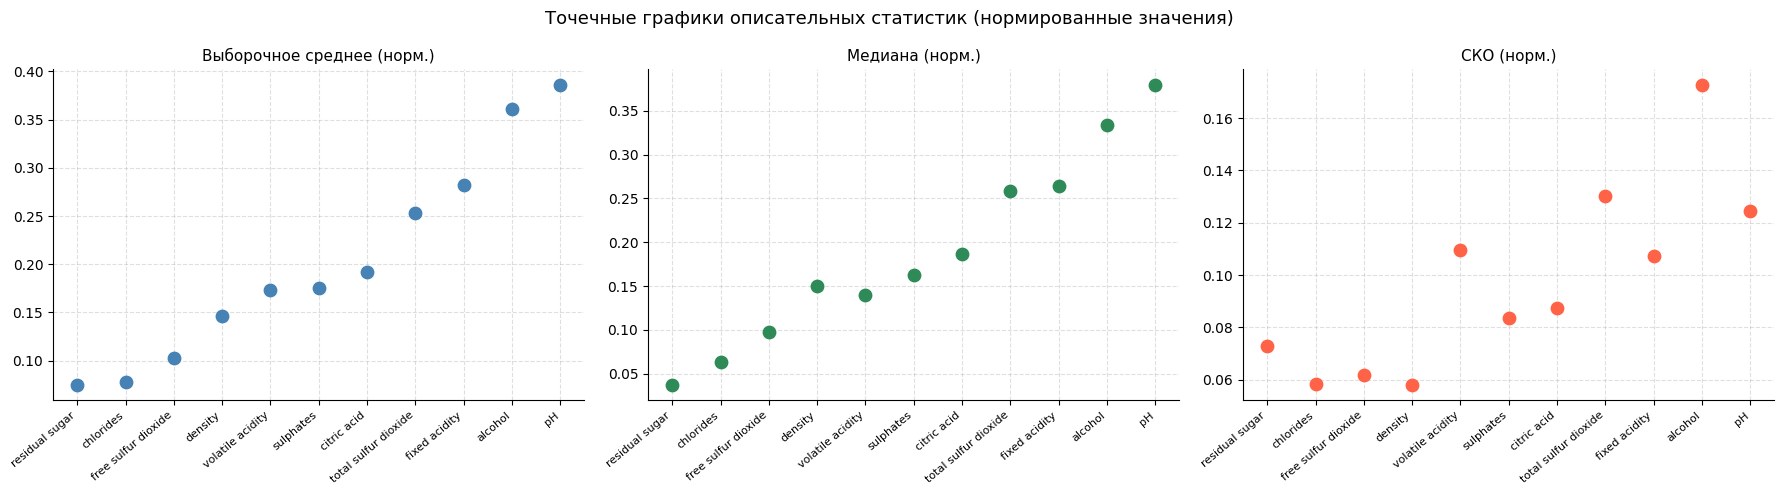

Параметры с наибольшим СКО (наибольшая вариабельность):
total sulfur dioxide    56.522
free sulfur dioxide     17.749
residual sugar           4.758
fixed acidity            1.296
alcohol                  1.193
volatile acidity         0.165
pH                       0.161
sulphates                0.149
citric acid              0.145
chlorides                0.035
density                  0.003
dtype: float64


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Нормируем [0,1] для наглядного сравнения
scaler = MinMaxScaler()
df_norm_vals = pd.DataFrame(scaler.fit_transform(df[numeric_cols]),
                             columns=numeric_cols)

means_norm   = df_norm_vals.mean().sort_values()
medians_norm = df_norm_vals.median().reindex(means_norm.index)
stds_norm    = df_norm_vals.std().reindex(means_norm.index)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for ax, vals, title, color in zip(
        axes,
        [means_norm, medians_norm, stds_norm],
        ['Выборочное среднее (норм.)', 'Медиана (норм.)', 'СКО (норм.)'],
        ['steelblue', 'seagreen', 'tomato']):
    ax.scatter(vals.index, vals.values, color=color, s=80, zorder=3)
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(vals.index, rotation=40, ha='right', fontsize=8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('Точечные графики описательных статистик (нормированные значения)', fontsize=13)
fig.tight_layout()
plt.show()

print('Параметры с наибольшим СКО (наибольшая вариабельность):')
print(df[numeric_cols].std().sort_values(ascending=False).round(3))

### 3. Гистограммы числовых параметров - с разбивкой по классам quality_label

Наложим гистограммы для regular (синий) и good (красный) вин.

In [6]:
# Вспомогательная функция построения гистограмм для набора признаков
def hist_for_attribute_set(df, labels, ax, bin_num=30, df2=None,
                           y_scale='linear', color1='steelblue', color2='tomato'):
    for i, col in enumerate(labels):
        ax[i].set_yscale(y_scale)
        ax[i].tick_params(labelsize=9)
        ax[i].set_xlabel(col, fontsize=9)
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)

        ax[i].hist(df[col], bins=bin_num, color=color1, alpha=0.7, label='regular')

        if df2 is not None and not df2.empty:
            ax[i].hist(df2[col], bins=bin_num, color=color2, alpha=0.6, label='good')

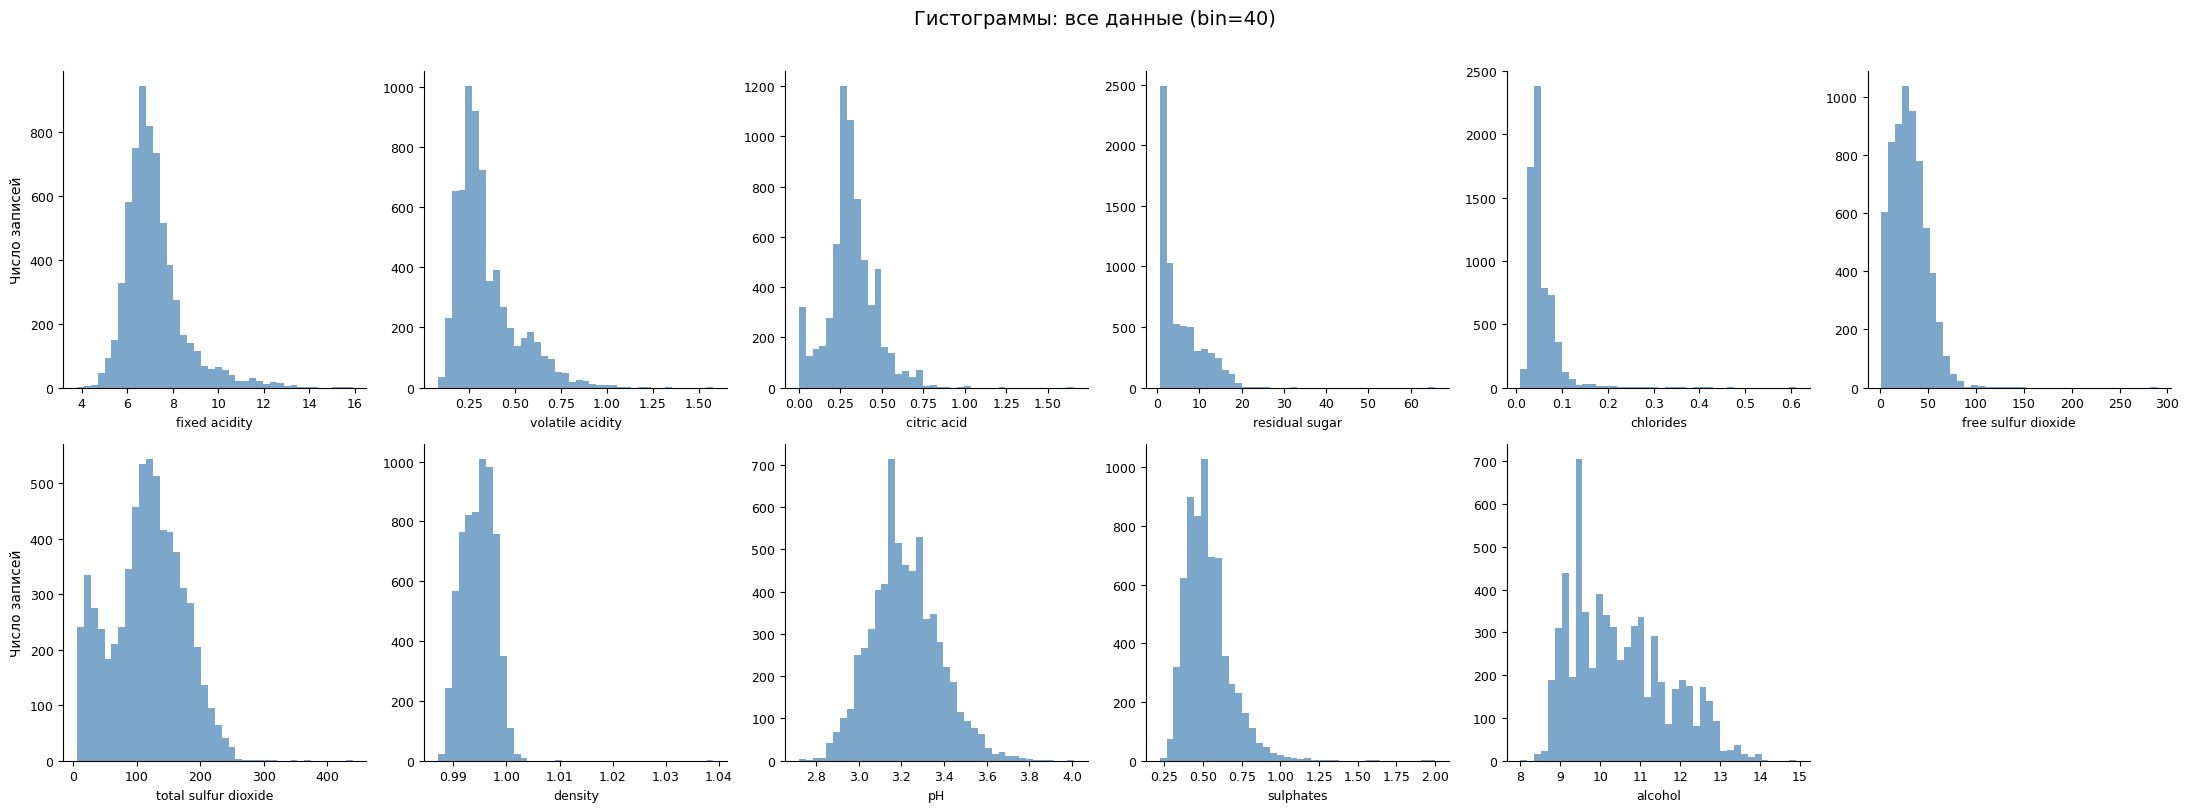

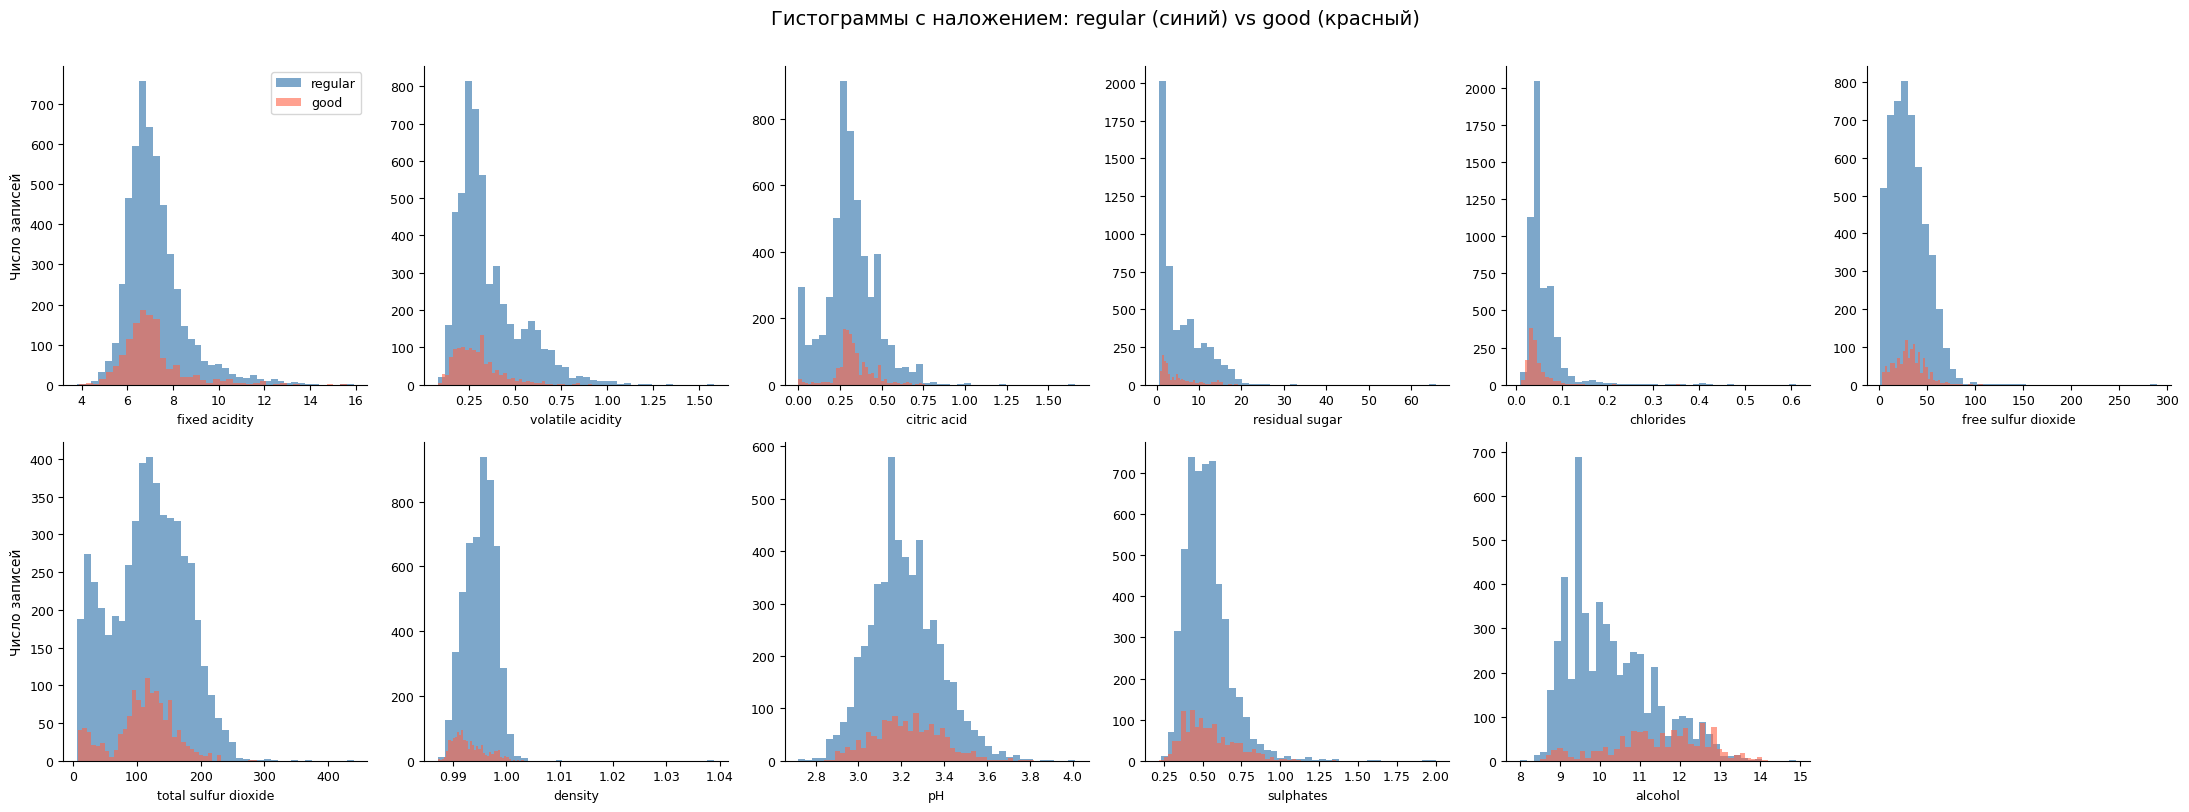

In [7]:
df_good    = df[df['quality_label'] == 'good']
df_regular = df[df['quality_label'] == 'regular']

# --- Часть 1: Все данные без разбивки (базовый вид) ---
fig, ax = plt.subplots(nrows=2, ncols=6, figsize=(22, 8))
axes = ax.flatten()
hist_for_attribute_set(df, numeric_cols, axes[:11], bin_num=40, y_scale='linear')
axes[11].set_visible(False)
axes[0].set_ylabel('Число записей')
axes[6].set_ylabel('Число записей')
plt.suptitle('Гистограммы: все данные (bin=40)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# --- Часть 2: Наложение good vs regular ---
# Поэкспериментируйте с bin_num (5, 15, 50) и y_scale ('linear', 'log', 'symlog')
fig2, ax2 = plt.subplots(nrows=2, ncols=6, figsize=(22, 8))
axes2 = ax2.flatten()
hist_for_attribute_set(df_regular, numeric_cols, axes2[:11],
                       bin_num=40, df2=df_good, y_scale='linear')
axes2[11].set_visible(False)
axes2[0].set_ylabel('Число записей')
axes2[6].set_ylabel('Число записей')

# Общая легенда
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='steelblue', alpha=0.7, label='regular'),
              Patch(facecolor='tomato',    alpha=0.6, label='good')]
axes2[0].legend(handles=legend_els, fontsize=9)

plt.suptitle('Гистограммы с наложением: regular (синий) vs good (красный)', fontsize=14, y=1.01)
fig2.tight_layout()
plt.show()

Наблюдения по наложенным гистограммам:
- `alcohol`: хорошие вина явно смещены вправо (выше алкоголь) - лучший разделяющий признак.
- `volatile acidity`: хорошие вина смещены влево (ниже летучая кислотность).
- `residual sugar`, `chlorides`, `free/total SO₂`: распределения обоих классов очень похожи - эти признаки слабее для классификации.
- `sulphates`: у хороших вин наблюдается небольшое смещение вправо.

Поэкспериментируйте с `y_scale='log'` - при логарифмической шкале лучше видны хвосты распределений.

### 4. Ящик с усами (Box Plot) - выявление выбросов

In [8]:
def boxplot_for_attribute_set(df, labels, ax, ylabel=None):
    flierprops = dict(marker='o', markersize=3, linestyle='none',
                      markerfacecolor='tomato', alpha=0.5)
    for i, col in enumerate(labels):
        ax.boxplot(df[col], positions=[i + 1], flierprops=flierprops,
                   medianprops=dict(color='navy', linewidth=2))
    ax.set_xticks(np.arange(len(labels)) + 1, labels, rotation=30, ha='right', fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.5)

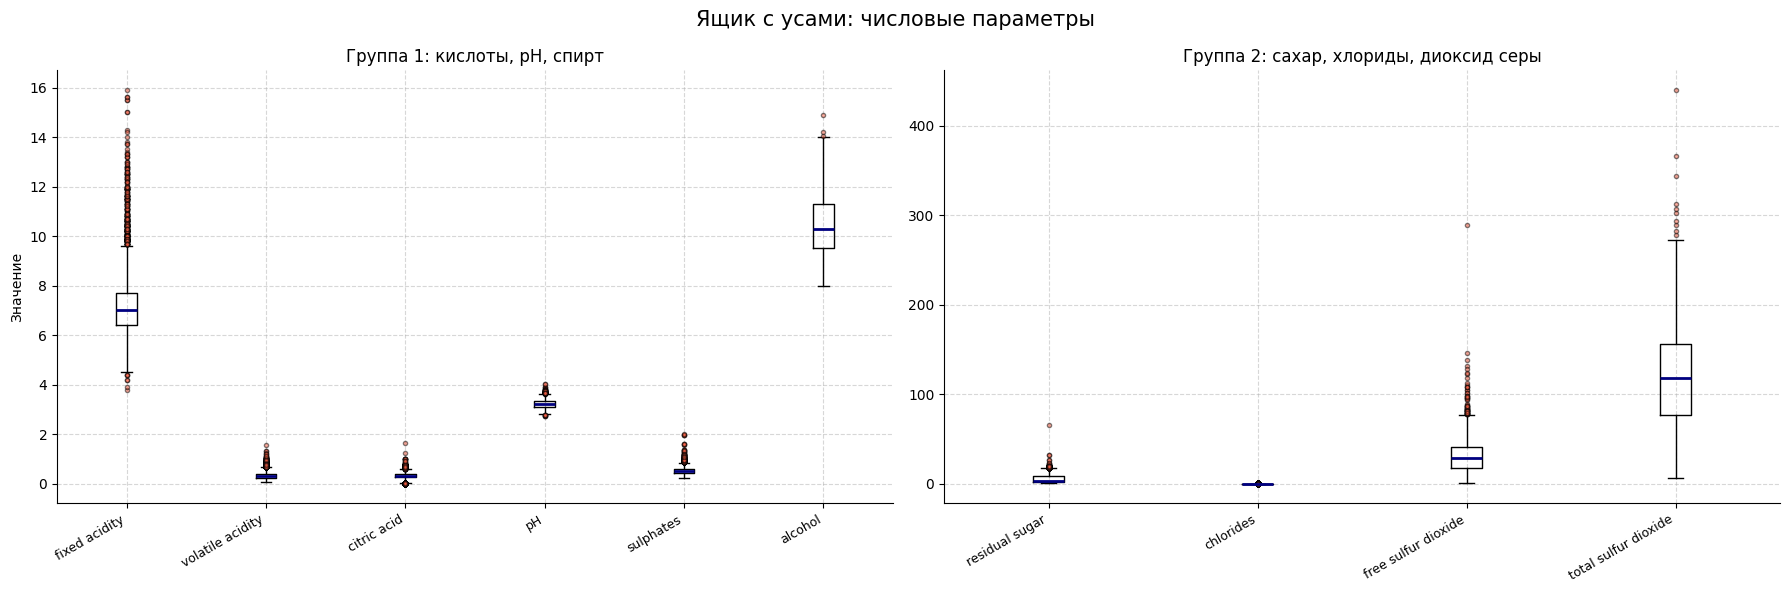

In [9]:
# Группируем признаки по близким диапазонам значений
group1 = ['fixed acidity', 'volatile acidity', 'citric acid', 'pH', 'sulphates', 'alcohol']
group2 = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

boxplot_for_attribute_set(df, group1, axes[0], ylabel='Значение')
axes[0].set_title('Группа 1: кислоты, pH, спирт', fontsize=12)

boxplot_for_attribute_set(df, group2, axes[1])
axes[1].set_title('Группа 2: сахар, хлориды, диоксид серы', fontsize=12)

plt.suptitle('Ящик с усами: числовые параметры', fontsize=15)
fig.tight_layout()
plt.show()

Вывод по выбросам (Вопрос 1):

Выбросы присутствуют в следующих атрибутах:
- `residual sugar` - единичные значения до ~65 г/л при медиане ~3 г/л (критически скошено)
- `chlorides` - выбросы до ~0.6 при медиане ~0.05
- `free sulfur dioxide` и `total sulfur dioxide` - максимумы в 289 и 440 мг/л значительно превышают Q3
- `volatile acidity` - есть правые выбросы
- `sulphates` - отдельные значения свыше 1.5
- `density` - несколько значений >1.01 (характерно для сладких вин с высоким содержанием сахара)

Выбросы в большинстве случаев физически обоснованы (экстремальные, но реальные образцы вин), однако при обучении классификатора их следует учитывать.

### 5. Скрипичная диаграмма (Violin Plot)

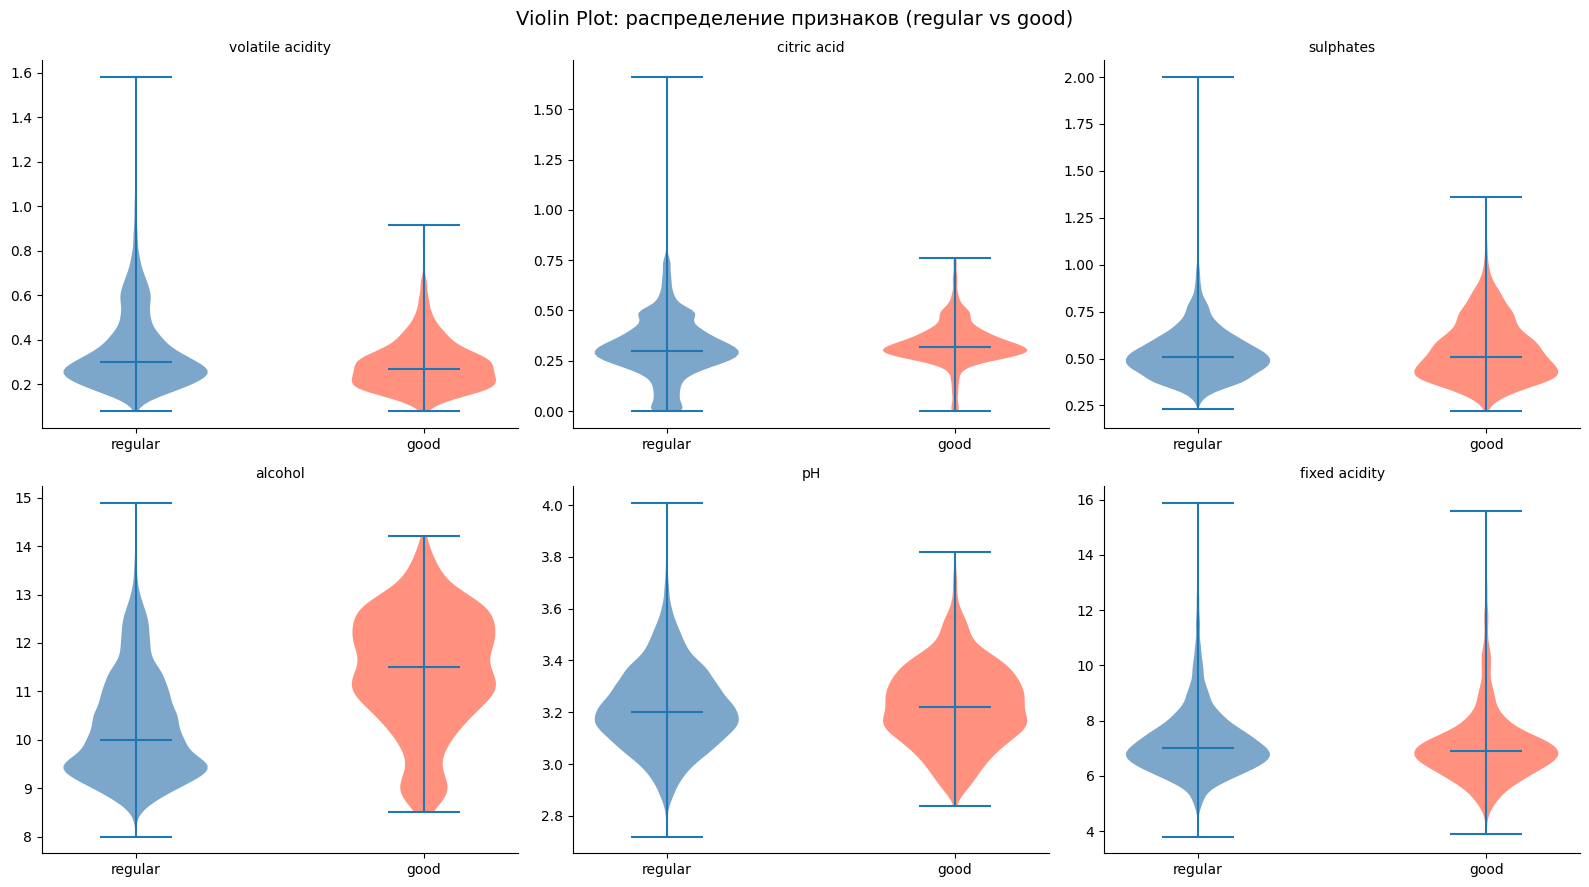

In [10]:
# Violin plot для признаков с нормальным диапазоном - сравнение good vs regular
cols_violin = ['volatile acidity', 'citric acid', 'sulphates', 'alcohol', 'pH', 'fixed acidity']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cols_violin):
    data_groups = [df[df['quality_label'] == 'regular'][col].dropna(),
                   df[df['quality_label'] == 'good'][col].dropna()]
    parts = axes[i].violinplot(data_groups, positions=[1, 2], showmedians=True)

    # Цветовое оформление
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['steelblue', 'tomato'][j])
        pc.set_alpha(0.7)

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([1, 2], ['regular', 'good'])
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)

plt.suptitle('Violin Plot: распределение признаков (regular vs good)', fontsize=14)
fig.tight_layout()
plt.show()

Наблюдения:
- `alcohol`: хорошие вина имеют явно более высокое содержание алкоголя - распределения хорошо разделимы.
- `volatile acidity`: у хороших вин значительно ниже - летучая кислотность вредит вкусу.
- `sulphates`: у хороших вин несколько выше - сульфаты действуют как антиоксидант.
- `citric acid`: хорошие вина содержат больше лимонной кислоты (свежесть вкуса).
- `pH` и `fixed acidity`: распределения схожи, различия незначительны.

### 6. Анализ номинального признака - тип вина (red / white)

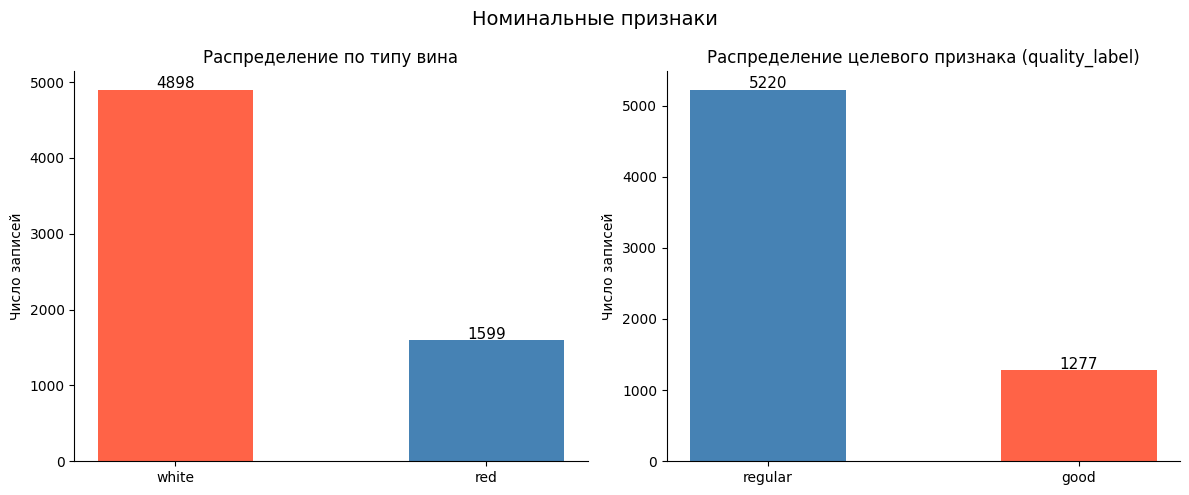

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Распределение типов вина
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['tomato', 'steelblue'], width=0.5)
axes[0].set_title('Распределение по типу вина', fontsize=12)
axes[0].set_ylabel('Число записей')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Распределение классов качества
label_counts = df['quality_label'].value_counts()
axes[1].bar(label_counts.index, label_counts.values,
            color=['steelblue', 'tomato'], width=0.5)
axes[1].set_title('Распределение целевого признака (quality_label)', fontsize=12)
axes[1].set_ylabel('Число записей')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=11)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.suptitle('Номинальные признаки', fontsize=14)
fig.tight_layout()
plt.show()

Наблюдения:
- Белого вина (~4898) в датасете примерно в 3 раза больше, чем красного (~1599).
- Классы несбалансированы: "обычных" вин (~5320) значительно больше, чем "хороших" (~1177, quality ≥ 7). Это важно учитывать при обучении классификатора - необходима балансировка выборки (oversampling / class_weight).

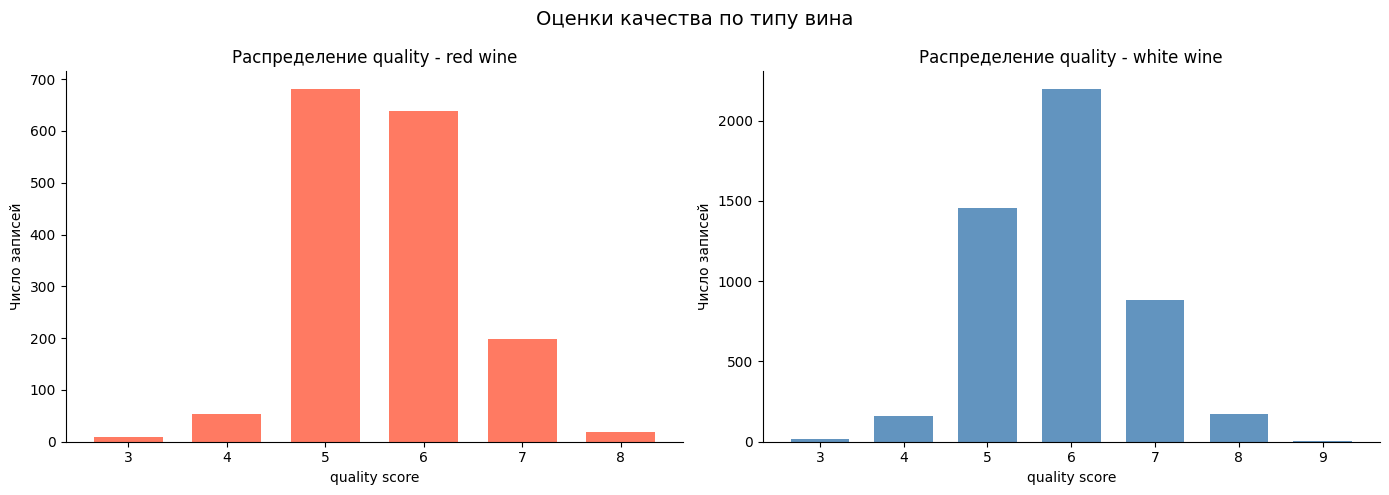

In [12]:
# Распределение оценок качества по каждому типу вина
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

for ax, wine_type, color in zip(axes, ['red', 'white'], ['tomato', 'steelblue']):
    subset = df[df['type'] == wine_type]['quality'].value_counts().sort_index()
    ax.bar(subset.index, subset.values, color=color, width=0.7, alpha=0.85)
    ax.set_title(f'Распределение quality - {wine_type} wine', fontsize=12)
    ax.set_xlabel('quality score')
    ax.set_ylabel('Число записей')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.suptitle('Оценки качества по типу вина', fontsize=14)
fig.tight_layout()
plt.show()

Оба типа вина имеют похожее нормальное распределение оценок с пиком в 5-6. Оценки ниже 3 и выше 9 крайне редки - это граничные случаи, заслуживающие отдельного внимания.

### 7. Вопрос 2 - Переходные процессы

Набор данных Wine Quality не является киберфизическими данными (временных рядов нет - каждая запись независима). Переходных периодов, в течение которых система выходит на режим, не существует. Порядок записей в файле не несёт временного смысла.

Для подтверждения визуализируем изменение нескольких признаков по порядку строк:

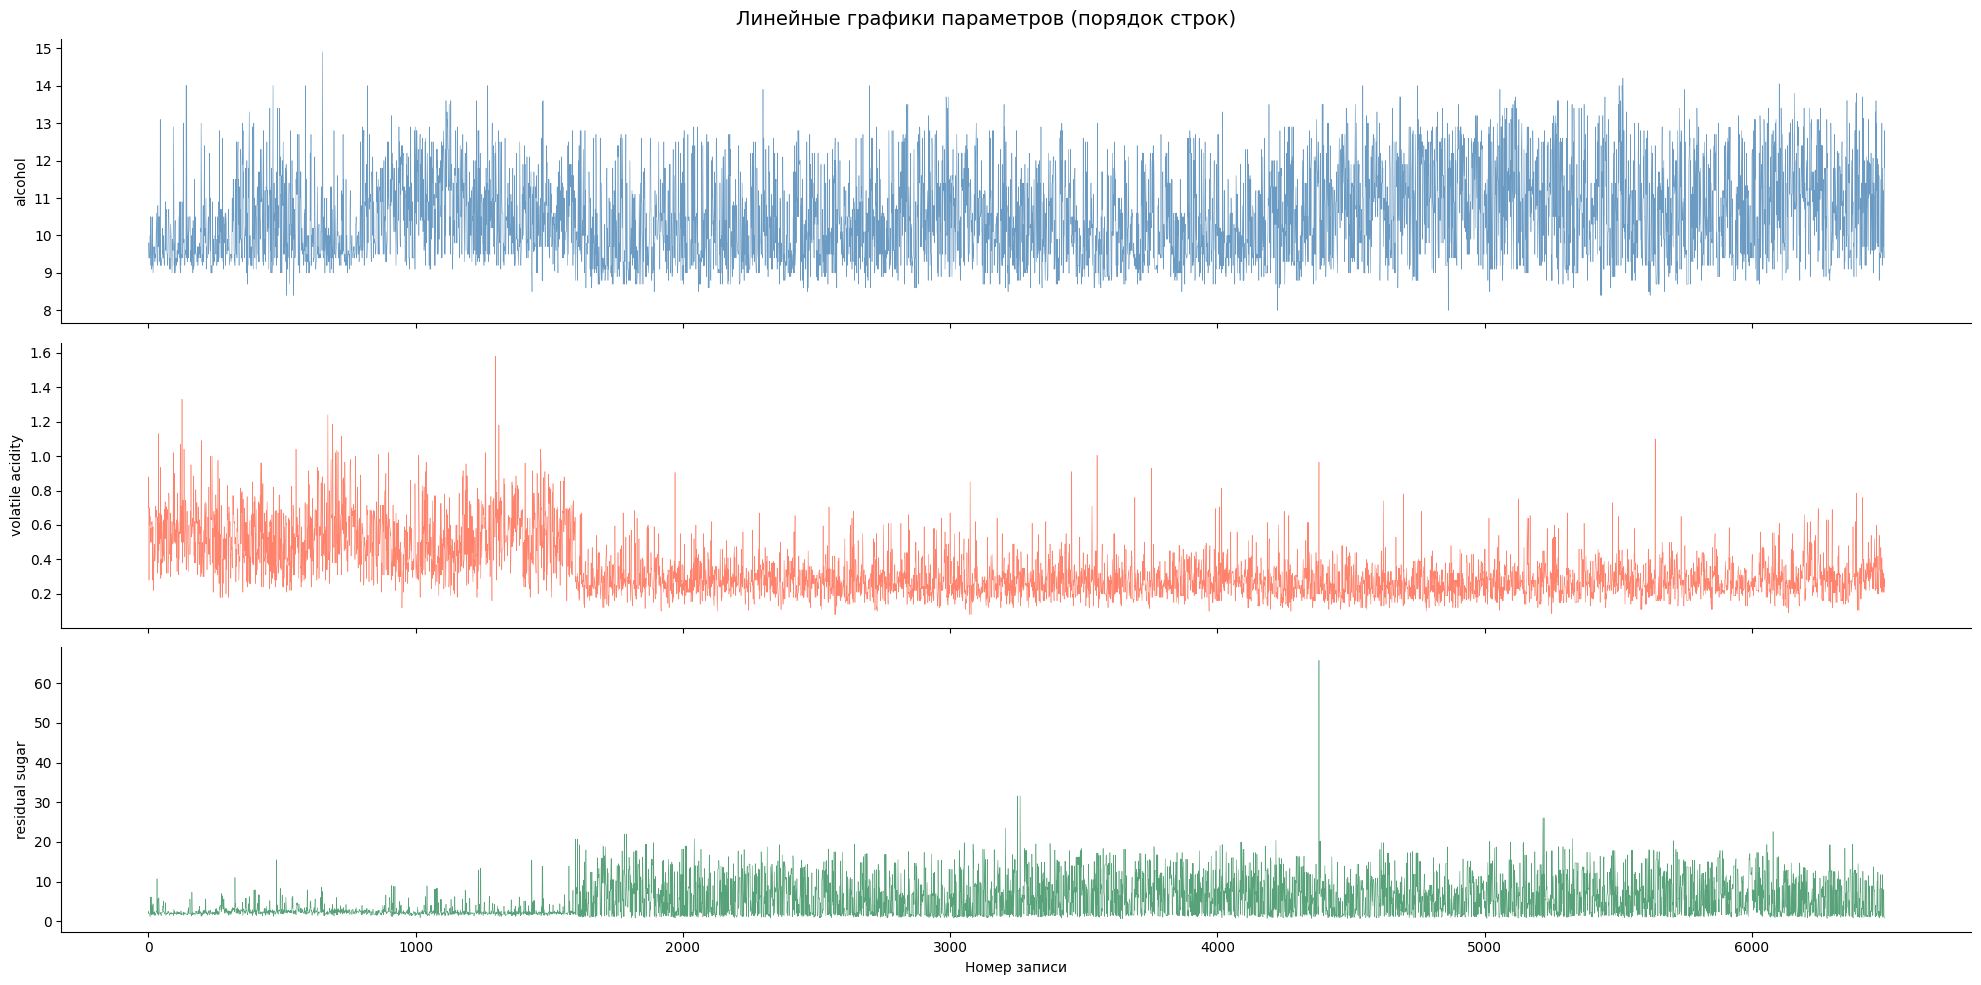

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 10), sharex=True)

cols_line = ['alcohol', 'volatile acidity', 'residual sugar']
colors_line = ['steelblue', 'tomato', 'seagreen']

for ax, col, c in zip(axes, cols_line, colors_line):
    ax.plot(df.index, df[col], color=c, linewidth=0.4, alpha=0.8)
    ax.set_ylabel(col, fontsize=10)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axes[-1].set_xlabel('Номер записи')
plt.suptitle('Линейные графики параметров (порядок строк)', fontsize=14)
fig.tight_layout()
plt.show()

График подтверждает: характерных переходных процессов нет. Примерно после записи ~1598 заметен сдвиг в распределении значений - это объясняется структурой файла: первые ~1599 записей - красное вино, остальные - белое. Это особенность объединения двух датасетов, а не переходный физический процесс.

---
## Двумерный анализ данных
### 8. Матрица корреляции

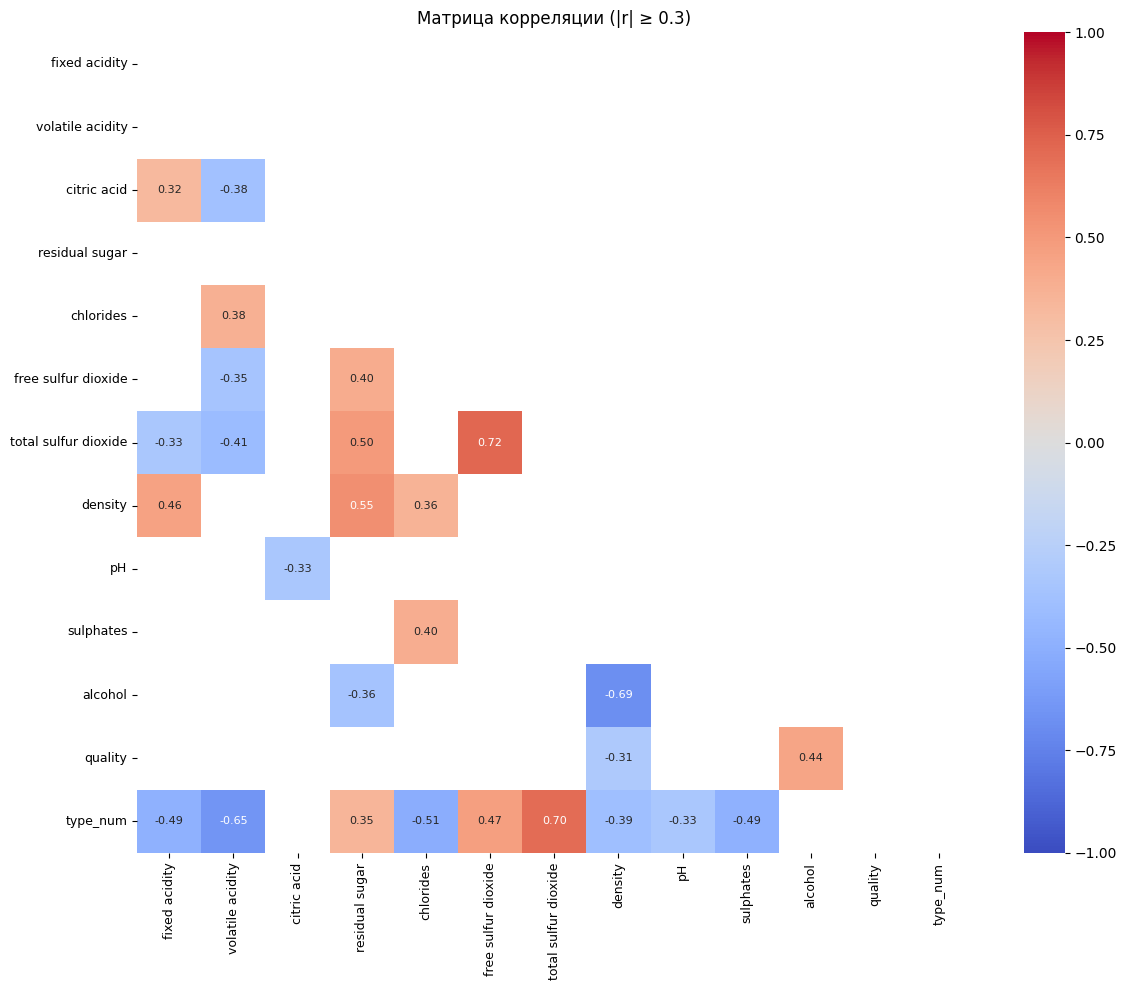

In [14]:
def plot_heatmap(df, ax, title, threshold=0.3):
    corr = df.corr(numeric_only=True)
    # Показываем только значимые корреляции
    df_corr = corr[(corr >= threshold) | (corr <= -threshold)]
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(df_corr, cbar=True, mask=mask, ax=ax,
                annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, annot_kws={'size': 8})
    ax.set_title(title, fontsize=12)
    ax.tick_params(labelsize=9)

# Добавим числовое кодирование типа вина и качества
df_corr_data = df[numeric_cols + ['quality']].copy()
df_corr_data['type_num'] = (df['type'] == 'white').astype(int)  # 1=white, 0=red

fig, ax = plt.subplots(figsize=(12, 10))
plot_heatmap(df_corr_data, ax, 'Матрица корреляции (|r| ≥ 0.3)', threshold=0.3)
fig.tight_layout()
plt.show()

Ключевые корреляции с целевым признаком `quality`:
- `alcohol` (+0.44) - наибольшая положительная корреляция
- `volatile acidity` (−0.27) - отрицательная: летучая кислотность снижает качество
- `density` (−0.31) - обратная связь (высокая плотность -> больше сахара -> ниже алкоголь -> хуже оценка)

Мультиколлинеарность:
- `density` и `residual sugar` (+0.55) - высокая взаимосвязь
- `density` и `alcohol` (−0.69) - сильная обратная связь (физически обоснована: чем больше сахара сброжено в алкоголь, тем ниже плотность)
- `free SO₂` и `total SO₂` (+0.72) - очевидная зависимость

### 9. Диаграммы рассеяния - ключевые пары признаков

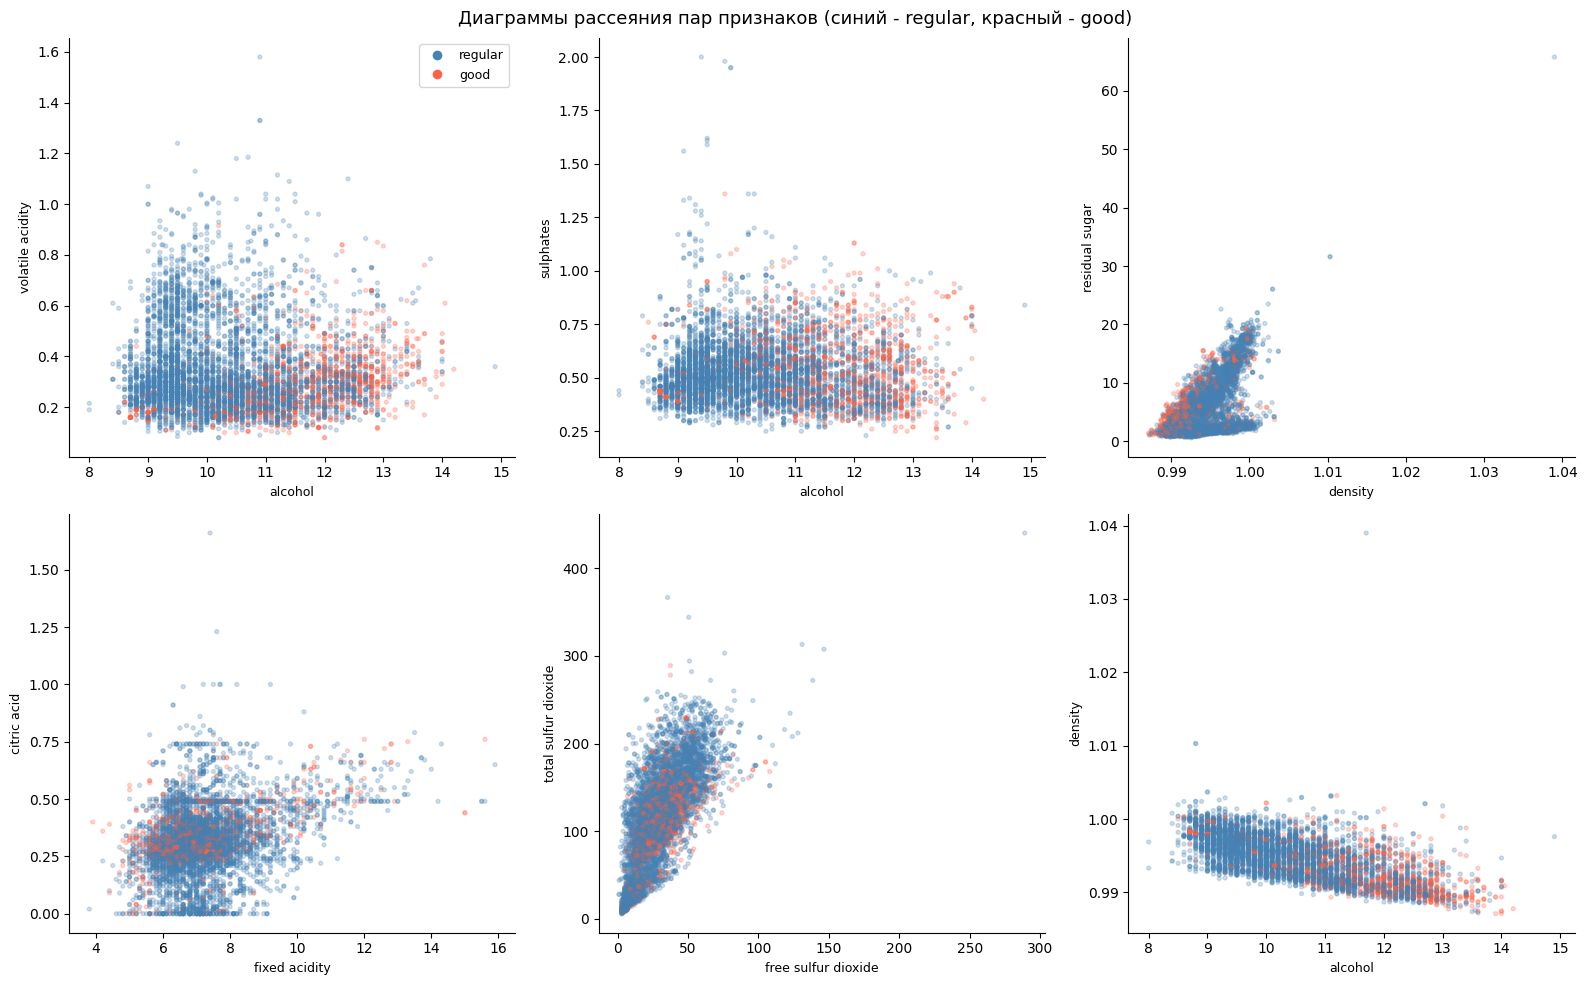

In [15]:
# Цветовое кодирование по классу качества
color_map = {'regular': 'steelblue', 'good': 'tomato'}
colors = [color_map[l] for l in df['quality_label']]

pairs = [
    ('alcohol', 'volatile acidity'),
    ('alcohol', 'sulphates'),
    ('density', 'residual sugar'),
    ('fixed acidity', 'citric acid'),
    ('free sulfur dioxide', 'total sulfur dioxide'),
    ('alcohol', 'density'),
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(df[x_col], df[y_col], c=colors, alpha=0.25, s=8)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Легенда
from matplotlib.lines import Line2D
legend_els = [Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=c, markersize=8, label=l)
              for l, c in color_map.items()]
axes[0].legend(handles=legend_els, fontsize=9)

plt.suptitle('Диаграммы рассеяния пар признаков (синий - regular, красный - good)',
             fontsize=13)
fig.tight_layout()
plt.show()

Наблюдения:
- `alcohol` vs `volatile acidity`: хорошие вина (красные точки) концентрируются в зоне высокого алкоголя и низкой летучей кислотности - хорошая разделимость классов!
- `alcohol` vs `density`: чёткая отрицательная линейная зависимость, хорошие вина смещены вправо (выше алкоголь, ниже плотность).
- `free SO₂` vs `total SO₂`: явная линейная корреляция, классы перемешаны - эта пара не информативна для классификации.
- `density` vs `residual sugar`: нелинейная зависимость с выбросами при высоком содержании сахара.

### 10. Scatter Matrix - наиболее интересные признаки

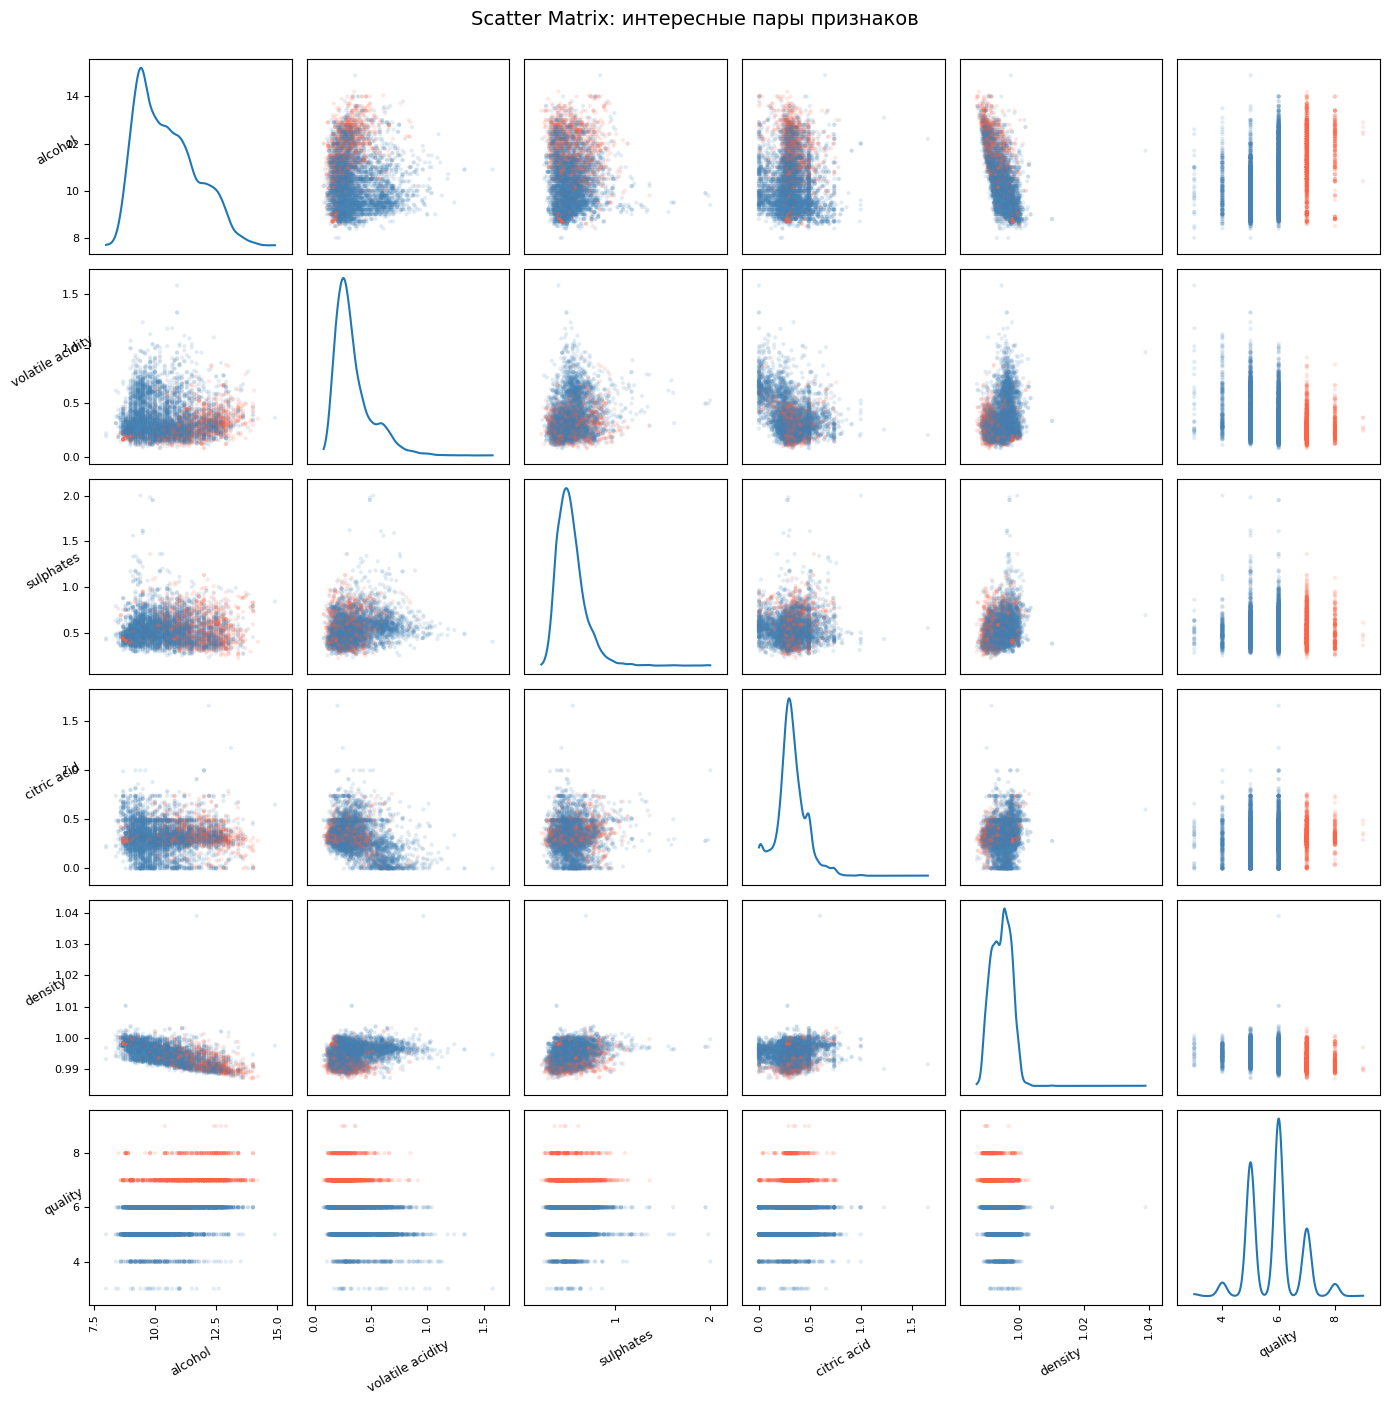

In [16]:
# Отбираем наиболее информативные для классификации признаки
interesting_cols = ['alcohol', 'volatile acidity', 'sulphates',
                    'citric acid', 'density', 'quality']

colors_scatter = ['tomato' if l == 'good' else '#4682B4' for l in df['quality_label']]

axes = scatter_matrix(df[interesting_cols], alpha=0.15, figsize=(14, 14),
                      range_padding=0.2, diagonal='kde', color=colors_scatter)

plt.suptitle('Scatter Matrix: интересные пары признаков', fontsize=14, y=1.0)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(30)
    ax.yaxis.label.set_rotation(30)
    ax.xaxis.label.set_fontsize(9)
    ax.yaxis.label.set_fontsize(9)

plt.tight_layout()
plt.show()

Наилучшее разделение классов (красные точки отделяются от синих) наблюдается в парах:
- `alcohol` / `volatile acidity`
- `alcohol` / `density`
- `sulphates` / `volatile acidity`

---
## Многомерный анализ - PCA проекция

In [17]:
X = df[numeric_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

print('Объяснённая дисперсия по компонентам:', pca.explained_variance_ratio_.round(3))
print('Суммарная объяснённая дисперсия (PC1+PC2+PC3):',
      pca.explained_variance_ratio_[:3].sum().round(3))

Объяснённая дисперсия по компонентам: [0.275 0.227 0.141]
Суммарная объяснённая дисперсия (PC1+PC2+PC3): 0.644


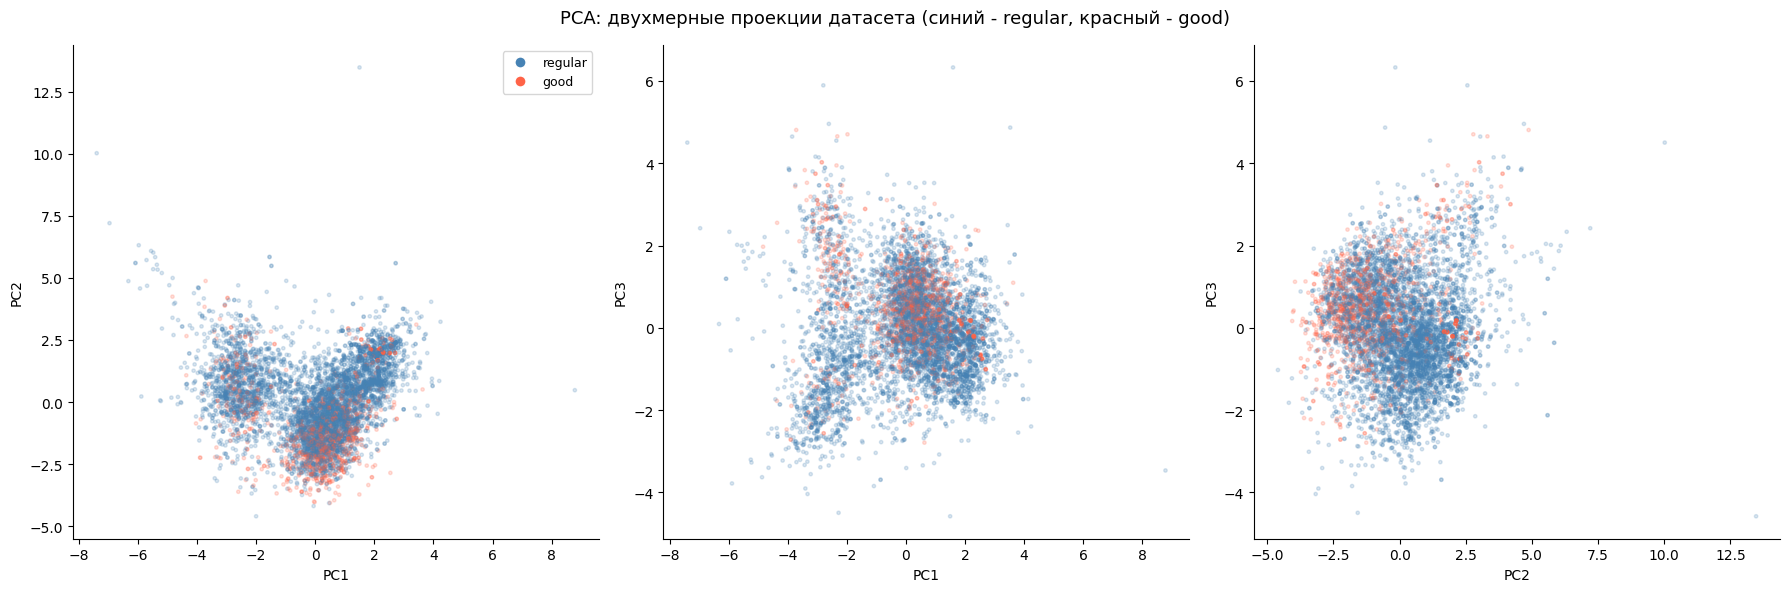

In [18]:
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2', 'PC3'])
c_pca = ['tomato' if l == 'good' else '#4682B4' for l in df['quality_label']]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for ax, (x, y) in zip(axes, [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]):
    ax.scatter(pca_df[x], pca_df[y], c=c_pca, alpha=0.2, s=6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

legend_els = [Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=c, markersize=8, label=l)
              for l, c in color_map.items()]
axes[0].legend(handles=legend_els, fontsize=9)

plt.suptitle('PCA: двухмерные проекции датасета (синий - regular, красный - good)',
             fontsize=13)
fig.tight_layout()
plt.show()

Три главные компоненты объясняют ~60–65% дисперсии (типичный результат для разнородных физико-химических данных). В проекции PC1–PC2 хорошие вина (красные) заметно смещены вправо - PC1 улавливает основное различие между классами, что коррелирует с алкоголем и плотностью.

---
## Итоговые выводы

### Вопрос 1: Выбросы
Выбросы присутствуют в следующих атрибутах:
- `residual sugar` - значения до 65 г/л (медиана ~3 г/л), характерно для сладких белых вин
- `chlorides` - редкие значения >0.4 (медиана ~0.05)
- `free sulfur dioxide` и `total sulfur dioxide` - максимумы в 289 и 440 мг/л
- `volatile acidity`, `sulphates` - правые хвосты с единичными выбросами
- `density` - значения >1.01 (связаны с высоким содержанием сахара)

Большинство выбросов физически обоснованы и не являются ошибками измерений.

### Вопрос 2: Переходные процессы
Набор данных не является киберфизическим - это статические измерения независимых образцов вина. Временного порядка между записями нет, переходные процессы отсутствуют. Визуальный "сдвиг" на линейном графике около записи 1600 объясняется объединением двух файлов (красное -> белое вино).

### Вопрос 3: Наиболее информативные атрибуты для классификации
По результатам анализа наиболее интересны для задачи классификации:

1. `alcohol` (корр. +0.44) - самый сильный предиктор: хорошие вина содержат больше алкоголя; распределения классов хорошо разделены
2. `volatile acidity` (корр. −0.27) - чем выше летучая кислотность (уксусный вкус), тем ниже оценка; violin plot показывает чёткое разделение
3. `sulphates` (корр. +0.25) - сульфаты как антиоксидант улучшают вкус и стабильность вина
4. `citric acid` (корр. +0.09, но визуально значима) - добавляет свежести, характерно для лучших образцов
5. `density` (корр. −0.31) - сильно коррелирует с alcohol, несёт комплексную информацию о составе вина

Признаки с низкой информативностью: `free/total sulfur dioxide`, `pH`, `fixed acidity` - их распределения практически одинаковы для обоих классов.

### Необходимые преобразования данных:
- Нормализация (StandardScaler) - из-за разных диапазонов признаков
- Логарифмирование `residual sugar`, `chlorides`, `sulphates` - для уменьшения влияния выбросов
- Балансировка классов (SMOTE или `class_weight='balanced'`) - 82% vs 18%